<a href="https://colab.research.google.com/github/Akanshajoshiiii/SpeechLAB/blob/main/Copy_of_Lab7_CNN_using_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import the necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Initialize the Hyper-parameters
num_epochs = 5
batch_size = 4
learning_rate = 0.001

In [ ]:
# transforming dataset images to tensor and further normalizing the three channels with mean as 0.5 and standard deviation as 0.5
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [ ]:
# CIFAR10: 60000 32x32 color images in 10 classes, with 6000 images per class
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:08<00:00, 19.2MB/s]


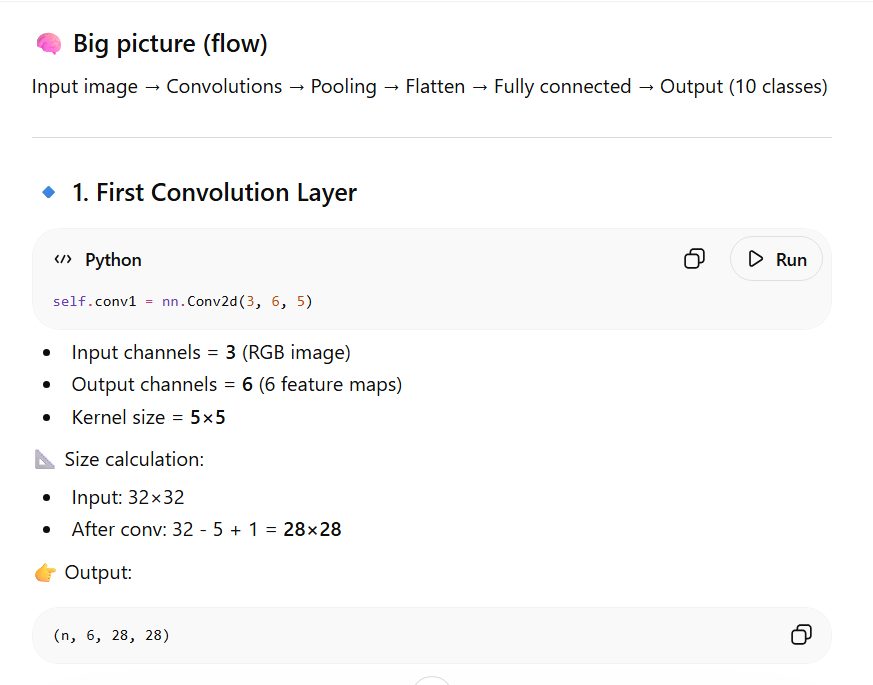

In [ ]:
#Model class for CNN
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)#3 input channels, 6 output channels, 5 kernel size, output image size: 28X28
        self.pool = nn.MaxPool2d(2, 2)#14X14 output image size
        #(kernel size,stride)  pooling
        self.conv2 = nn.Conv2d(6, 16, 5)#6 input channels, 16 output, kernel size: 5X5, output size: 10X10, max pool ==> output size 5x5
        #flatten
        #400 inputs ja rahe hain
        #120 neurons unko process kar rahe hain
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # -> n, 3, 32, 32
        x = self.pool(F.relu(self.conv1(x)))  # -> n, 6, 14, 14
        #print(x.shape)
        x = self.pool(F.relu(self.conv2(x)))  # -> n, 16, 5, 5==> 3d matrix
        #print(x.shape)
        x = x.view(-1, 16 * 5 * 5)            # -> n, 400
        x = F.relu(self.fc1(x))               # -> n, 120
        x = F.relu(self.fc2(x))               # -> n, 84
        x = self.fc3(x)                       # -> n, 10
        return x




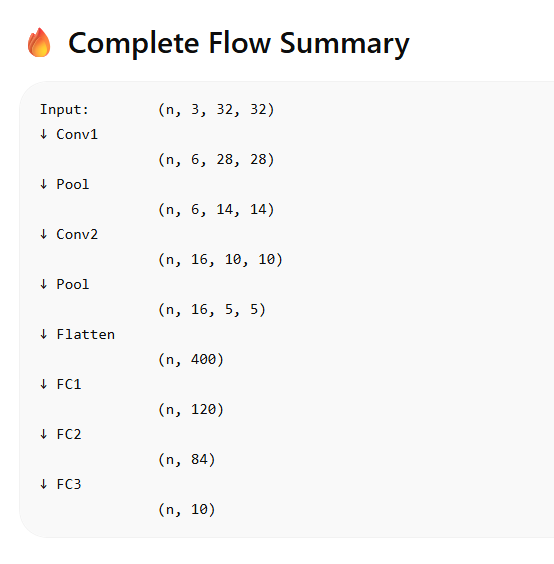

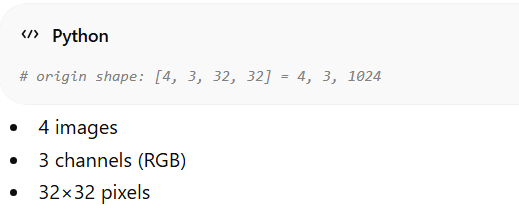

In [ ]:
#training
model = ConvNet()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

n_total_steps = len(train_loader) #Number of batches in one epoch
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # origin shape: [4, 3, 32, 32] = 4, 3, 1024
        # input_layer: 3 input channels, 6 output channels, 5 kernel size

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if (i+1) % 2000 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

print('Finished Training')
PATH = './cnn.pth'
torch.save(model.state_dict(), PATH)

Epoch [1/5], Step [2000/12500], Loss: 2.2761
Epoch [1/5], Step [4000/12500], Loss: 2.2930
Epoch [1/5], Step [6000/12500], Loss: 2.3133
Epoch [1/5], Step [8000/12500], Loss: 2.3081
Epoch [1/5], Step [10000/12500], Loss: 2.2573
Epoch [1/5], Step [12000/12500], Loss: 2.3046
Epoch [2/5], Step [2000/12500], Loss: 2.1723
Epoch [2/5], Step [4000/12500], Loss: 2.2344
Epoch [2/5], Step [6000/12500], Loss: 2.1680
Epoch [2/5], Step [8000/12500], Loss: 1.9499
Epoch [2/5], Step [10000/12500], Loss: 1.4061
Epoch [2/5], Step [12000/12500], Loss: 1.8909
Epoch [3/5], Step [2000/12500], Loss: 1.6542
Epoch [3/5], Step [4000/12500], Loss: 2.0435
Epoch [3/5], Step [6000/12500], Loss: 1.3528
Epoch [3/5], Step [8000/12500], Loss: 2.1308
Epoch [3/5], Step [10000/12500], Loss: 1.3898
Epoch [3/5], Step [12000/12500], Loss: 1.2729
Epoch [4/5], Step [2000/12500], Loss: 1.1070
Epoch [4/5], Step [4000/12500], Loss: 1.5394
Epoch [4/5], Step [6000/12500], Loss: 1.7806
Epoch [4/5], Step [8000/12500], Loss: 1.8906
Epoc

Assignment: Implement CNN using MNIST dataset